# 01 — Cleaning the data and first look at the market

**Data:** one CSV from [Inside Airbnb](https://insideairbnb.com/get-the-data/)
— the Berlin snapshot of **26 June 2026**: 12,855 listings, 19 columns.
Details and download steps: [`data/README.md`](../data/README.md).

**In this notebook:** check what is in the file, remove listings that do not
belong in a short-term price analysis, and look at who supplies this market.

The cleaning rules live in [`src/cleaning.py`](../src/cleaning.py), with
three tests in [`tests/test_cleaning.py`](../tests/test_cleaning.py).

In [12]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import config as cfg
from src import cleaning

sns.set_theme(style="whitegrid", palette="colorblind")
np.random.seed(cfg.SEED)

In [13]:
raw = cleaning.load_listings()
print(raw.shape)
raw.drop(columns=["license"]).head(3)   # license column excluded on purpose - see below

(12855, 19)


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,3176,Fabulous Flat in great Location,3718.0,1.462506e+18,Britta,Pankow,Prenzlauer Berg Südwest,52.53574,13.41734,Entire home/apt,161.0,2.0,150,2025-08-09,0.72,1.0,342,1
1,9991,Geourgeous flat - outstanding views,33852.0,1.462507e+18,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,193.0,6.0,7,2020-01-04,0.05,1.0,261,0
2,14325,Studio Apartment in Prenzlauer Berg,55531.0,1.462508e+18,Chris Und Oliver,Pankow,Prenzlauer Berg Nordwest,52.54624,13.40575,Entire home/apt,NaN,180.0,26,2023-11-30,0.13,2.0,211,0


> **Privacy note:** under EU rules in force since 20 May 2026, the `license`
> column can contain real host names and home addresses. This project never
> prints that raw text — `cleaning.licence_type()` turns it into a safe
> category (registration / company / person / missing), and that category is
> all we ever use.

In [14]:
# How much is missing in each column?
raw.isna().sum().sort_values(ascending=False).head(6)

price                4340
license              4046
reviews_per_month    2595
last_review          2595
host_profile_id        99
host_name              95
dtype: int64

A third of the listings have **no price**. Is that random? Let's check
against availability:

In [15]:
no_dates = raw["availability_365"] == 0

print(f"listings with zero available nights: {no_dates.sum():,}")
print(f"   of those, share with no price:  {raw.loc[no_dates, 'price'].isna().mean():.1%}")
print(f"listings WITH available nights:      {(~no_dates).sum():,}")
print(f"   of those, share with no price:  {raw.loc[~no_dates, 'price'].isna().mean():.1%}")

listings with zero available nights: 3,492
   of those, share with no price:  99.9%
listings WITH available nights:      9,363
   of those, share with no price:  9.1%


Almost every listing with nothing bookable has no price — Airbnb simply has
no price to show for them. So the missing prices are **systematic, not
random**: dropping them removes listings that are not really on the market,
not a random third of the data.

## The 92-night pattern

Berlin's short-term letting law
([Zweckentfremdungsverbot](https://www.berlin.de/sen/wohnen/rechtliches/zweckentfremdungsverbot/))
caps holiday-letting a second home at **90 days a year** — but lets of
**3 months or more** ("Wohnen auf Zeit") fall outside the law entirely.

Now look at the most common minimum-stay values:

In [16]:
print(raw["minimum_nights"].value_counts().head(5).to_string())
print()
over_90 = raw["minimum_nights"] > cfg.MAX_NIGHTS
print(f"listings requiring more than {cfg.MAX_NIGHTS} nights: {over_90.sum():,} ({over_90.mean():.1%})")

minimum_nights
92.0    3778
1.0     3722
2.0     2051
3.0     1219
4.0      423

listings requiring more than 90 nights: 4,170 (32.4%)


The **single most common minimum stay in Berlin is 92 nights** — more common
than 1 night. 92 nights is just over the 3-month line, so these listings sit
outside the short-term rules.

This pattern is *consistent with* hosts positioning outside the rules — the
data cannot prove intent. Either way they are a different market
(medium-term furnished rentals), so the price analysis excludes them.

## Does the registration rule show up in the data?

Since March 2023, Airbnb
[blocks short-term Berlin listings without a registration number](https://hnts.legal/post/zweckentfremdungsverbot-und-eu-meldepflicht---was-sich-in-berlin-ab-mai-2026-andert).
Long-stay listings do not need one. If that is true, licence display should
split along exactly that line:

In [17]:
feat = cleaning.add_columns(raw)

share = feat.groupby("is_short_term")["has_licence"].mean() * 100
print(f"short-term listings showing a licence: {share[True]:.1f}%")
print(f"long-stay listings showing a licence:  {share[False]:.1f}%")
print()
print("what kind of licence content (safe categories):")
print(feat["licence_type"].value_counts().to_string())

short-term listings showing a licence: 97.9%
long-stay listings showing a licence:  7.5%

what kind of licence content (safe categories):
licence_type
registration    4510
missing         4046
company         2602
person          1685
other             12


An almost perfect split: the registration rule is visibly enforced exactly
where it applies, and nowhere else. The categories also show something new —
under the EU disclosure rules, about 20% of listings are openly
**company-run** (a "Legal entity" disclosure).

## Cleaning

Three rules, from `src/cleaning.py`: keep listings with a usable price
(> 0 and ≤ 1000 EUR), a short-term minimum stay (≤ 90 nights), and some
sign of life (reviews or open dates).

In [18]:
df = cleaning.clean_listings(raw)
df.to_csv(cfg.CLEAN_FILE, index=False)
print(f"\nsaved -> {cfg.CLEAN_FILE.name}")

start:                              12,855 listings
with a usable price (<= 1000 EUR):    8,489
short-term only (<= 90 nights):     6,995
active (has reviews or open dates):  6,995

saved -> listings_clean.csv


In [19]:
# Headline numbers for the cleaned short-term market
print(f"listings:        {len(df):,}")
print(f"median price:    {df['price'].median():.0f} EUR / night")
print(f"mean price:      {df['price'].mean():.0f} EUR / night")
print(f"entire homes:    {df['is_entire_home'].mean():.0%}")

listings:        6,995
median price:    153 EUR / night
mean price:      182 EUR / night
entire homes:    70%


## Who supplies this market?

`calculated_host_listings_count` says how many Berlin listings each host
runs — so we can see how concentrated the market is.

In [20]:
hosts = raw.dropna(subset=["host_id"]).groupby("host_id")["id"].count()

big = hosts[hosts >= cfg.PROFESSIONAL_MIN]
print(f"hosts in total:            {len(hosts):,}")
print(f"hosts with 5+ listings:    {len(big):,}  ({len(big) / len(hosts):.1%} of hosts)")
print(f"listings they control:     {big.sum():,}  ({big.sum() / len(raw):.1%} of the market)")
print(f"largest single host runs:  {hosts.max()} listings")

hosts in total:            8,182
hosts with 5+ listings:    310  (3.8% of hosts)
listings they control:     3,525  (27.4% of the market)
largest single host runs:  261 listings


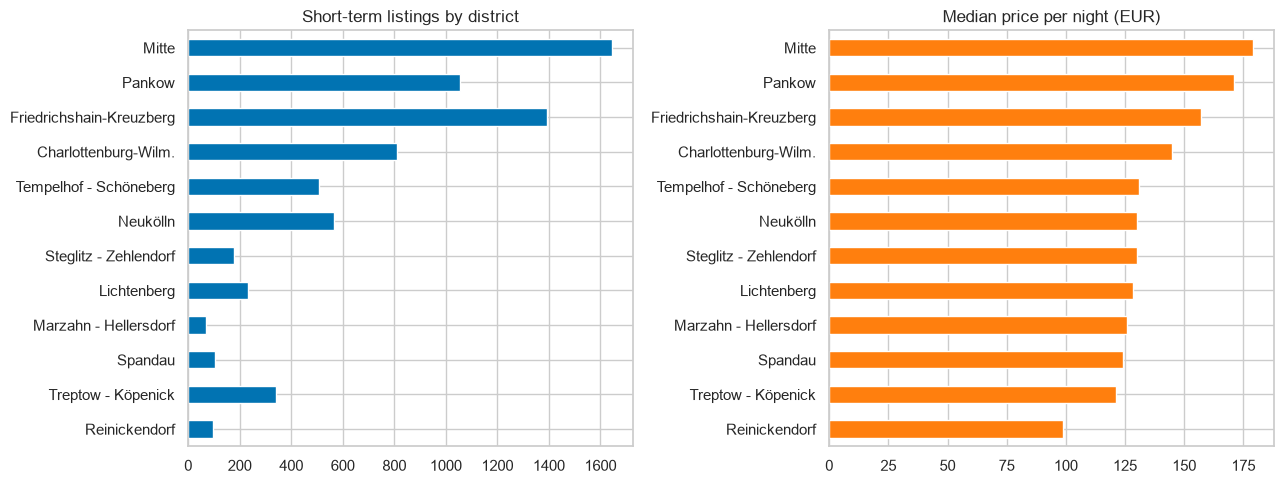

In [21]:
# Listings and median price by district
by_district = (df.groupby("neighbourhood_group")
                 .agg(listings=("id", "count"), median_price=("price", "median"))
                 .sort_values("median_price"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
by_district["listings"].plot.barh(ax=axes[0], title="Short-term listings by district")
by_district["median_price"].plot.barh(ax=axes[1], color="tab:orange",
                                      title="Median price per night (EUR)")
for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "01_districts.png", dpi=150, bbox_inches="tight")

## What I found

_Fill in after running:_

1. __% of listings have no price, and that is systematic: almost all of them
   have zero available nights.
2. The most common minimum stay is 92 nights; __% of the market sits above
   the 90-night threshold.
3. Licence display: __% of short-term listings vs __% of long-stay ones.
4. __% of hosts run 5+ listings and control __% of the market.
5. The cleaned short-term market: __ listings, median __ EUR/night.

**Next:** `02_statistics.ipynb` — how sure are we about these prices, and
which differences are real?